#  PREDICTING ESG TREND

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 

In [2]:
#Import data
df=pd.read_csv('data/company_esg_financial_dataset.csv')

In [3]:
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

### Fill in the missing data with meidan of the group(Growth Rate)*


In [5]:
df['GrowthRate'].fillna(df['GrowthRate'].median(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_11532\1629460023.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GrowthRate'].fillna(df['GrowthRate'].median(), inplace=True)


In [6]:
df.isna().sum()

CompanyID            0
CompanyName          0
Industry             0
Region               0
Year                 0
Revenue              0
ProfitMargin         0
MarketCap            0
GrowthRate           0
ESG_Overall          0
ESG_Environmental    0
ESG_Social           0
ESG_Governance       0
CarbonEmissions      0
WaterUsage           0
EnergyConsumption    0
dtype: int64

### Let's segment the data industry wise

In [7]:
indus_df = df.groupby('Industry')
indus_df

In [8]:
indus_df.size()

Industry
Consumer Goods    1276
Energy            1188
Finance           1243
Healthcare        1331
Manufacturing     1287
Retail            1166
Technology        1045
Transportation    1287
Utilities         1177
dtype: int64

### Convert objects to category

In [9]:
df_tmp = df.copy()

In [10]:
# Find the columns that contain string/object(Nan)

for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

CompanyName
Industry
Region


In [11]:
#Convert object to category
for label, content in df_tmp.items():
    if pd.api.types.is_object_dtype(content):
        df_tmp[label]=content.astype('category').cat.as_ordered()
        

In [12]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CompanyID          11000 non-null  int64   
 1   CompanyName        11000 non-null  category
 2   Industry           11000 non-null  category
 3   Region             11000 non-null  category
 4   Year               11000 non-null  int64   
 5   Revenue            11000 non-null  float64 
 6   ProfitMargin       11000 non-null  float64 
 7   MarketCap          11000 non-null  float64 
 8   GrowthRate         11000 non-null  float64 
 9   ESG_Overall        11000 non-null  float64 
 10  ESG_Environmental  11000 non-null  float64 
 11  ESG_Social         11000 non-null  float64 
 12  ESG_Governance     11000 non-null  float64 
 13  CarbonEmissions    11000 non-null  float64 
 14  WaterUsage         11000 non-null  float64 
 15  EnergyConsumption  11000 non-null  float64 
dtypes: c

## Exploratory data analysis (EDA)

In [13]:
#Aggregate industry-wise
industry_avg = df.groupby('Industry')[[
    'ESG_Overall',
    'CarbonEmissions',
    'WaterUsage',
    'EnergyConsumption'
]].mean()

<Figure size 640x480 with 0 Axes>

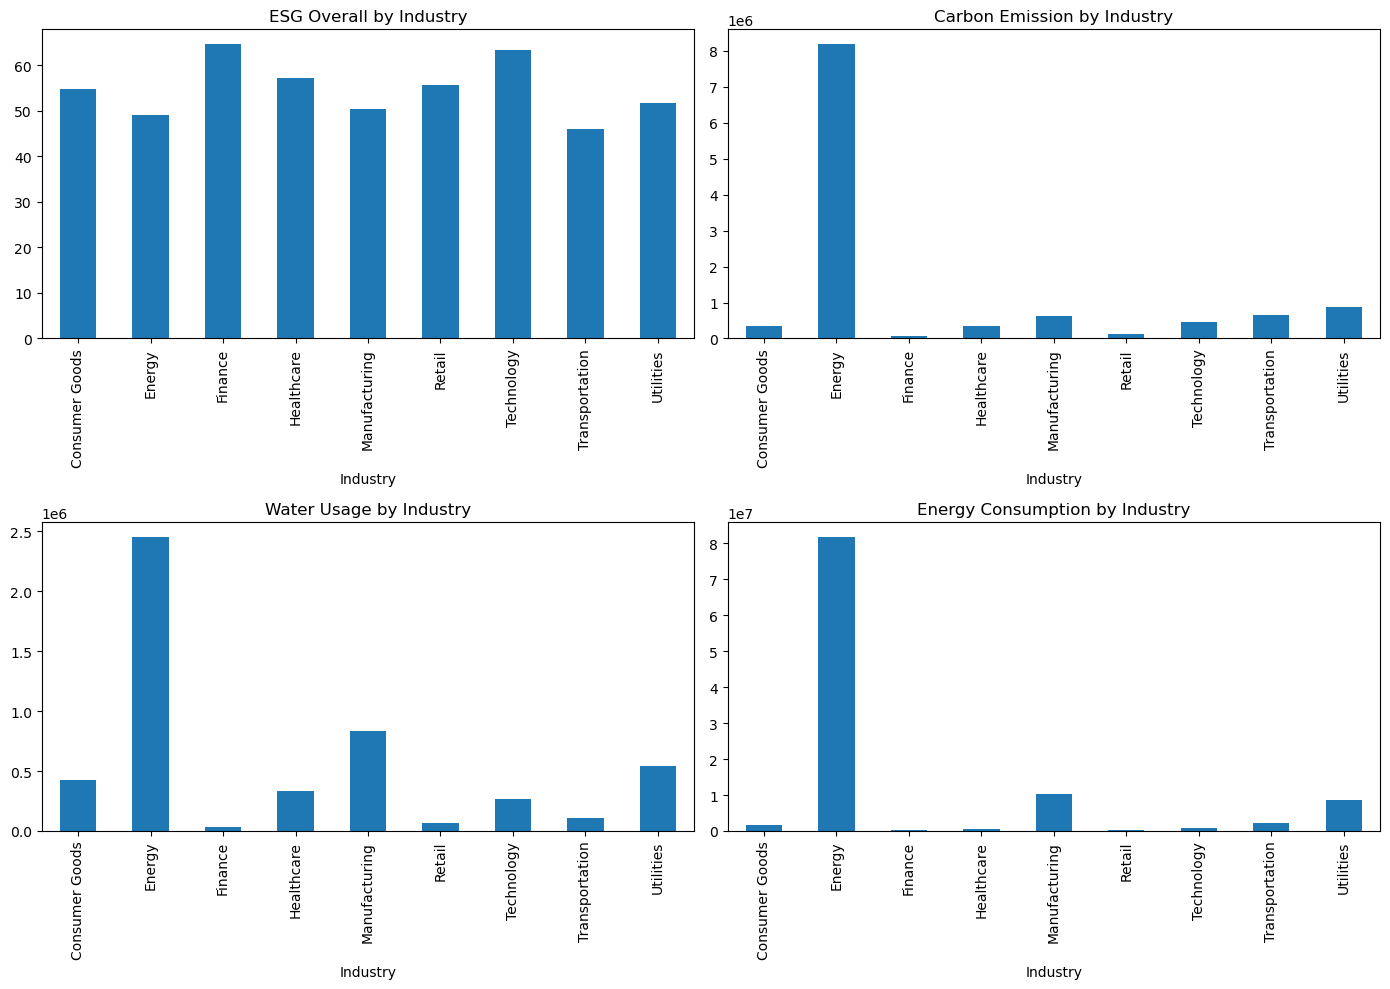

In [14]:
plt.figure() 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

industry_avg['ESG_Overall'].plot(kind='bar', ax=axes[0, 0], title='ESG Overall by Industry')
industry_avg['CarbonEmissions'].plot(kind='bar', ax=axes[0, 1], title='Carbon Emission by Industry')
industry_avg['WaterUsage'].plot(kind='bar', ax=axes[1, 0], title='Water Usage by Industry')
industry_avg['EnergyConsumption'].plot(kind='bar', ax=axes[1, 1], title='Energy Consumption by Industry')

plt.tight_layout()
plt.show();


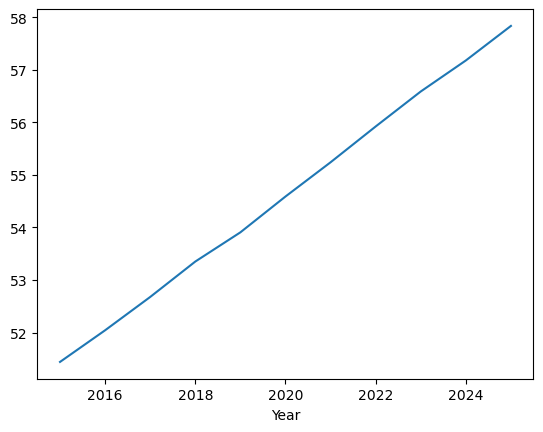

In [15]:
plt.figure()
df.groupby('Year')['ESG_Overall'].mean().plot(kind='line')
plt.show();

<Figure size 640x480 with 0 Axes>

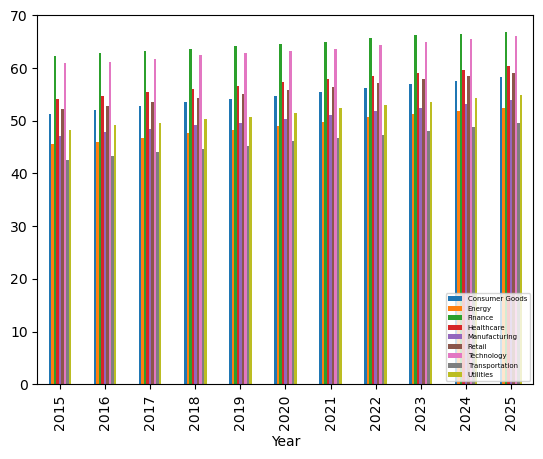

In [16]:
plt.figure()
df.groupby(['Year','Industry'])['ESG_Overall'].mean().unstack().plot(kind='bar')
plt.legend(loc='lower right', fontsize=5)
plt.show();

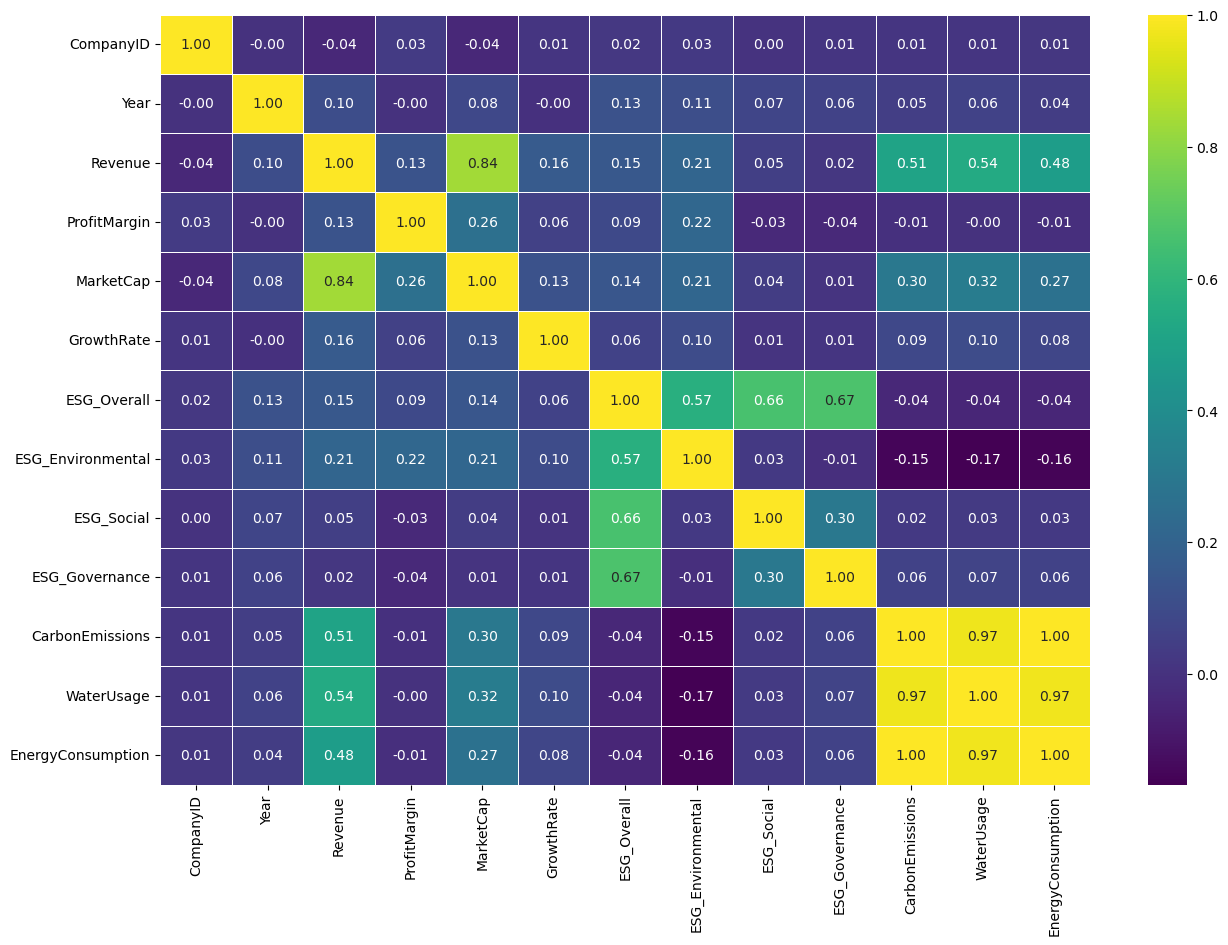

In [17]:
#make correlation matrix
import seaborn as sns
corr_mat = df.select_dtypes(include='number').corr()
fig,ax= plt.subplots(figsize=(15,10))
ax= sns.heatmap(corr_mat,annot=True,
                linewidths=0.5,fmt='.2f',
                cmap='viridis')
plt.show();

Yellow at bottom right indicates that Industries with high carbon emissions also: Use large amounts of water, Consume large amounts of energy

### Find outliers and treat them

In [18]:
num_cols = df.select_dtypes(include='number').columns

<Axes: >

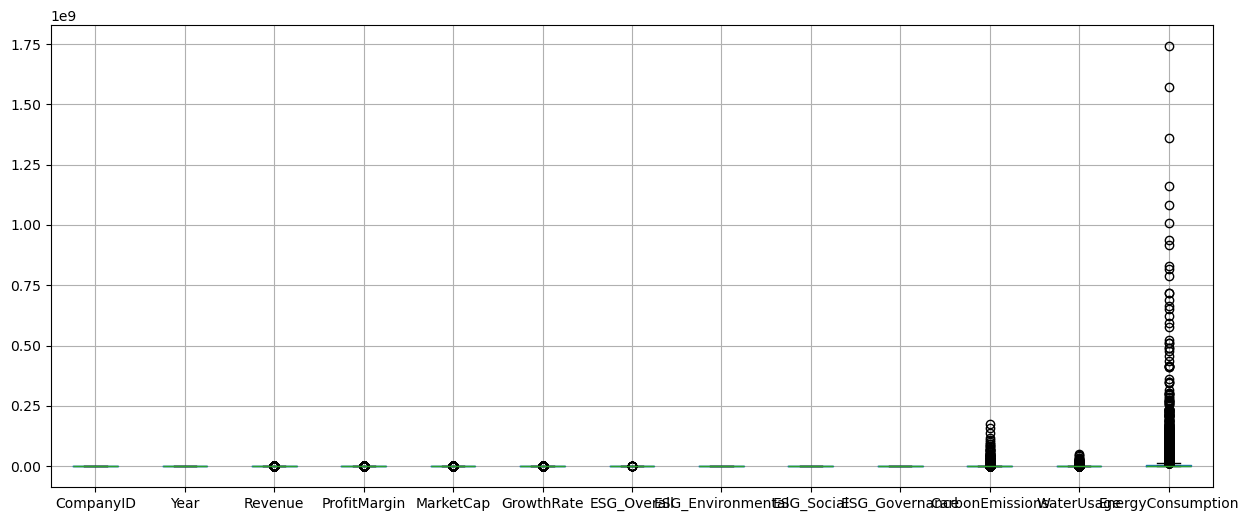

In [19]:
df[num_cols].boxplot(figsize=(15,6))

In [20]:
#Apply log transformation

df['CarbonEmissions'] = np.log1p(df['CarbonEmissions'])
df['WaterUsage'] = np.log1p(df['WaterUsage'])
df['EnergyConsumption'] = np.log1p(df['EnergyConsumption'])


In [21]:
#Create efficiency ratios

df['Carbon_per_Revenue'] = df['CarbonEmissions'] / df['Revenue']
df['Water_per_Revenue'] = df['WaterUsage'] / df['Revenue']
df['Energy_per_Revenue'] = df['EnergyConsumption'] / df['Revenue']


In [22]:
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,Carbon_per_Revenue,Water_per_Revenue,Energy_per_Revenue
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,4.9,57.0,60.7,33.5,76.8,10.479494,9.786375,11.172626,0.022821,0.021312,0.024331
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,10.527169,9.834052,11.220303,0.022219,0.020756,0.023682
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,10.714582,10.021457,11.407719,0.018967,0.017740,0.020194
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,10.660808,9.967687,11.353944,0.019092,0.017850,0.020333
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,10.640661,9.947538,11.333796,0.019190,0.017940,0.020440


<Axes: >

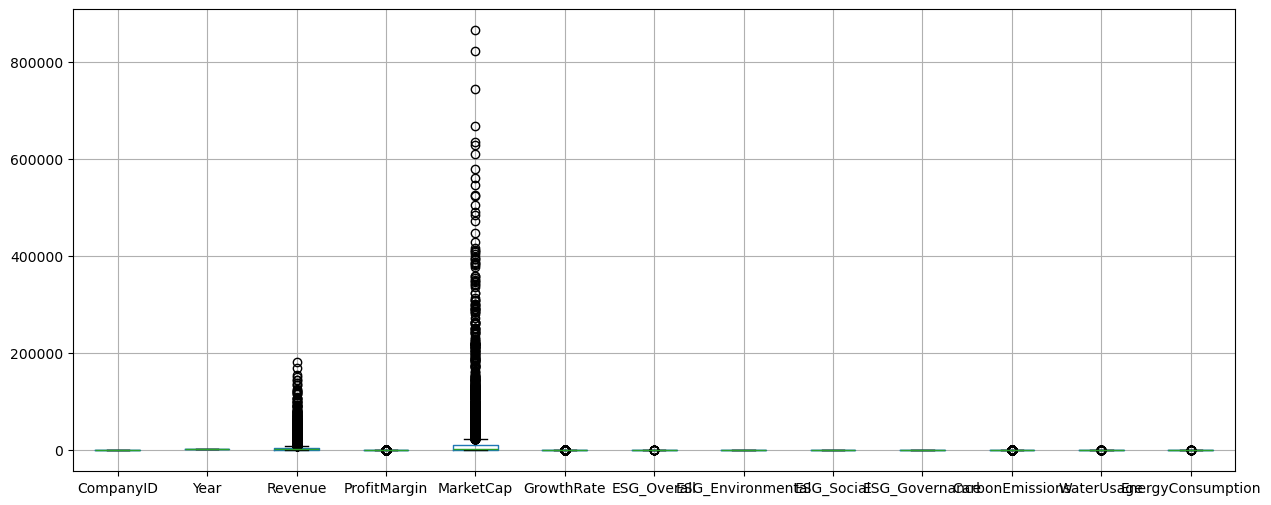

In [23]:
df[num_cols].boxplot(figsize=(15,6))

## Model fitting

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop('ESG_Overall',axis=1)
y = df['ESG_Overall']

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=1)

### Scale the data to ensure fair contibution of all features

In [36]:
# Select numeric columns only
numeric_cols = X_train.select_dtypes(include='number').columns
#Select categorical columns
categorical_cols = X_train.select_dtypes(include='category').columns

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


### Models we are gonna use 


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression


In [45]:
# 1. Linear Regression 
modelLinear= LinearRegression()
modelLinear.fit(X_train_processed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
modelLinear.predict(X_test_processed)

array([58.83372559, 40.36466033, 44.40177723, ..., 48.73280456,
       63.89990198, 50.63321055], shape=(2200,))

In [47]:
modelLinear.score(X_test_processed,y_test)

0.9999956657762076

In [49]:
# 2.Ridge regression
modelRidge = Ridge()
modelRidge.fit(X_train_processed,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [50]:
modelRidge.predict(X_test_processed)

array([58.83383525, 40.36804138, 44.40376277, ..., 48.73330771,
       63.89904574, 50.63405485], shape=(2200,))

In [51]:
modelRidge.score(X_test_processed,y_test)

0.9999956452410632

In [52]:
# 3.Random Forest Regressor
modelRandom = RandomForestRegressor()
modelRandom.fit(X_train_processed,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
modelRandom.predict(X_test_processed)

array([58.888, 40.94 , 43.772, ..., 48.143, 64.812, 50.289], shape=(2200,))

In [54]:
modelRandom.score(X_test_processed,y_test)

0.9974670448493804

In [55]:
train_score = modelRandom.score(X_train_processed, y_train)
test_score = modelRandom.score(X_test_processed, y_test)

print("Train:", train_score)
print("Test:", test_score)


Train: 0.9995879519760524
Test: 0.9974670448493804


In [58]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('preprocess', preprocessor),   # scaling + encoding
    ('model', RandomForestRegressor(random_state=1))
])

In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5)
print(scores)
print("Mean:", scores.mean())


[0.99015707 0.98997097 0.99191524 0.98998052 0.99215907]
Mean: 0.9908365739935


## Hyperparameter tunining

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [62]:
# 1.Linear Regression
y_pred1 = modelLinear.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred1))
r2 = r2_score(y_test, y_pred1)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.026261047024493053
RMSE: 0.033341055381302366
R²  : 0.9999956657762076


In [64]:
#2.Ridge Regression
y_pred2 = modelRidge.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
r2 = r2_score(y_test, y_pred2)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.026551171593907404
RMSE: 0.03341994543940719
R²  : 0.9999956452410632


In [65]:
#3.Random Forest Regressor
y_pred3 = modelRandom.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred3)
rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
r2 = r2_score(y_test, y_pred3)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.6028986363636358
RMSE: 0.8060044267304547
R²  : 0.9974670448493804


## Predict future ESG 

In [67]:
df = df.sort_values(['Industry', 'Year'])

df['ESG_Overall_next_year'] = (
    df.groupby('Industry')['ESG_Overall'].shift(-1)
)

In [68]:
df_future = df.dropna(subset=['ESG_Overall_next_year'])

In [69]:
X = df_future.drop(
    columns=['ESG_Overall', 'ESG_Overall_next_year']
)

y = df_future['ESG_Overall_next_year']


Split the data into training and test set based on year 

In [71]:
train = df_future[df_future['Year'] <= 2020]
test  = df_future[df_future['Year'] > 2020]

X_trainf = train[X.columns]
y_trainf = train[y.name]

X_testf = test[X.columns]
y_testf = test[y.name]


In [72]:
pipe.fit(X_trainf, y_trainf)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
y_predf = pipe.predict(X_testf)

In [74]:
print("MAE:", mean_absolute_error(y_testf, y_predf))
print("RMSE:", np.sqrt(mean_squared_error(y_testf, y_predf)))
print("R² :", r2_score(y_testf, y_predf))

MAE: 8.093939891805247
RMSE: 10.615655257863116
R² : 0.5465310372372694


### Hyperparameter tuning for future 

In [75]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 5, 10]
}

In [79]:
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=1
)

grid.fit(X_trainf, y_trainf)


,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 300]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [80]:
best_model = grid.best_estimator_
print(grid.best_params_)

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}


In [81]:
y_pred_future= best_model.predict(X_testf)

print("MAE :", mean_absolute_error(y_testf, y_pred_future))
print("RMSE:", np.sqrt(mean_squared_error(y_testf, y_pred_future)))
print("R²  :", r2_score(y_testf, y_pred_future))


MAE : 7.99404274360516
RMSE: 10.469677358051701
R²  : 0.5589167647755311
